# Requirements

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json

In [2]:
N_EXP = 5

# Functions

In [3]:
def load_results(path):
    with open(path, 'r') as f:
        results = json.load(f)

    return results

def get_cls_metrics(results):
    list_acc = []
    list_f1_macro = []
    list_f1_micro = []
    list_time = []

    for i in range(N_EXP):
        list_acc.append(results[i]['acc'])
        list_f1_macro.append(results[i]['f1_macro'])   
        list_f1_micro.append(results[i]['f1_micro'])
        list_time.append(results[i]['time'])

    metrics = {}
    metrics['mean_acc']  = np.mean(list_acc)
    metrics['std_acc'] = np.std(list_acc)
    metrics['mean_f1_macro'] = np.mean(list_f1_macro)
    metrics['std_f1_macro'] = np.std(list_f1_macro)
    metrics['mean_f1_micro'] = np.mean(list_f1_micro)
    metrics['std_f1_micro'] = np.std(list_f1_micro)
    metrics['mean_time'] = np.mean(list_time)
    metrics['std_time'] = np.std(list_time)

    return metrics

def get_tser_metrics(results):
    list_mse = []
    list_rmse = []
    list_mae = []
    list_time = []

    for i in range(N_EXP):
        list_mse.append(results[i]['mse'])
        list_rmse.append(results[i]['rmse'])   
        list_mae.append(results[i]['mae'])
        list_time.append(results[i]['time'])

    metrics = {}
    metrics['mean_mse']  = np.mean(list_mse)
    metrics['std_mse'] = np.std(list_mse)
    metrics['mean_rmse'] = np.mean(list_rmse)
    metrics['std_rmse'] = np.std(list_rmse)
    metrics['mean_mae'] = np.mean(list_mae)
    metrics['std_mae'] = np.std(list_mae)
    metrics['mean_time'] = np.mean(list_time)
    metrics['std_time'] = np.std(list_time)

    return metrics 

def plot_loss_graph(results, i):
    y1 = results[i]['train_losses'][10:]
    y2 = results[i]['val_losses'][10:]

    plt.plot(np.arange(10,len(y1)+10), y1, label='Train Loss')
    plt.plot(np.arange(10,len(y1)+10), y2, label='Validation Loss')
    plt.legend()
    plt.show()

def plot_confusion_matrix(results, i):
    y_pred = results[i]['y_pred']
    y_true = results[i]['y_true']

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

# Experiment Results

## Classification

  Acurácia:  0.32 +- 0.06
  F1 Macro:  0.26 +- 0.08
  F1 Micro:  0.32 +- 0.06
Time (sec):  12.73 +- 3.72


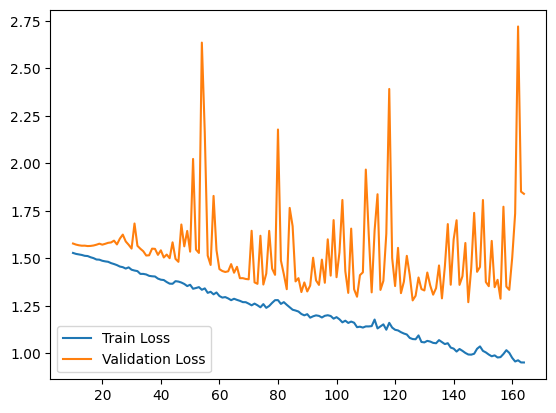

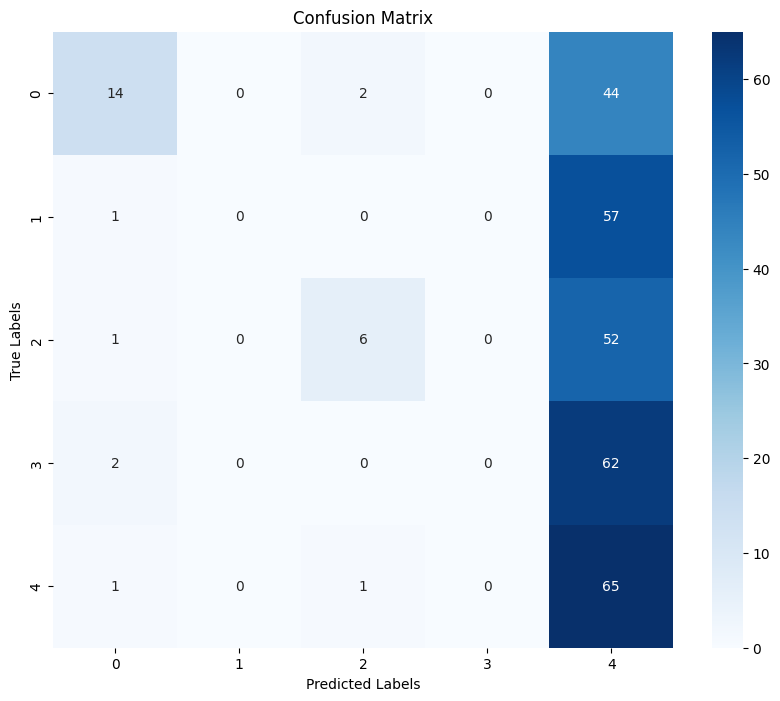

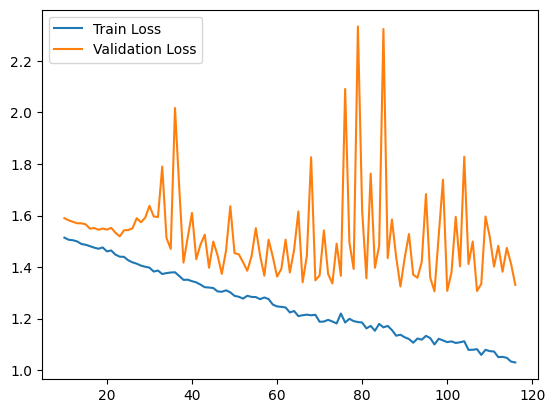

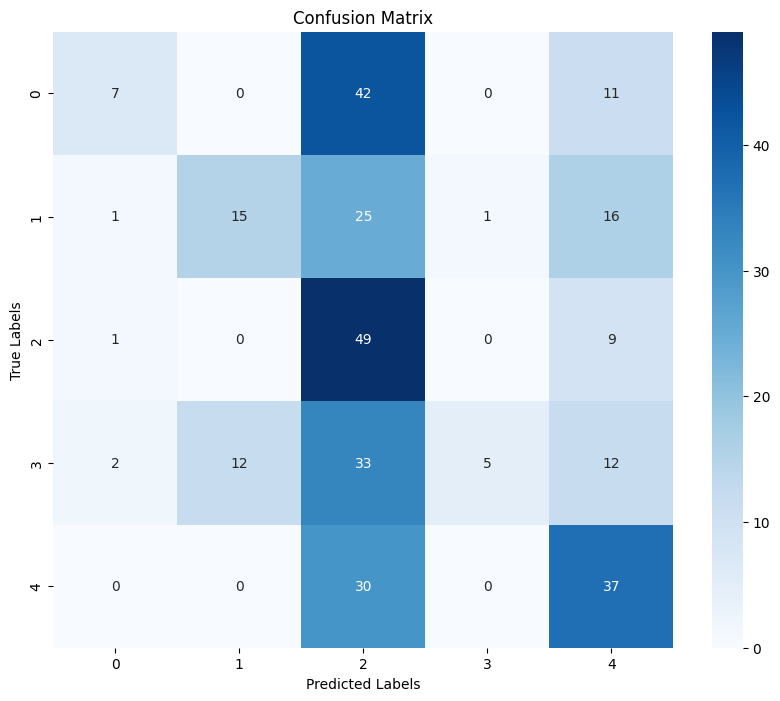

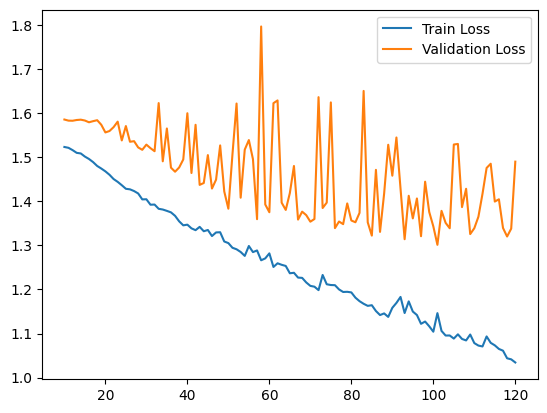

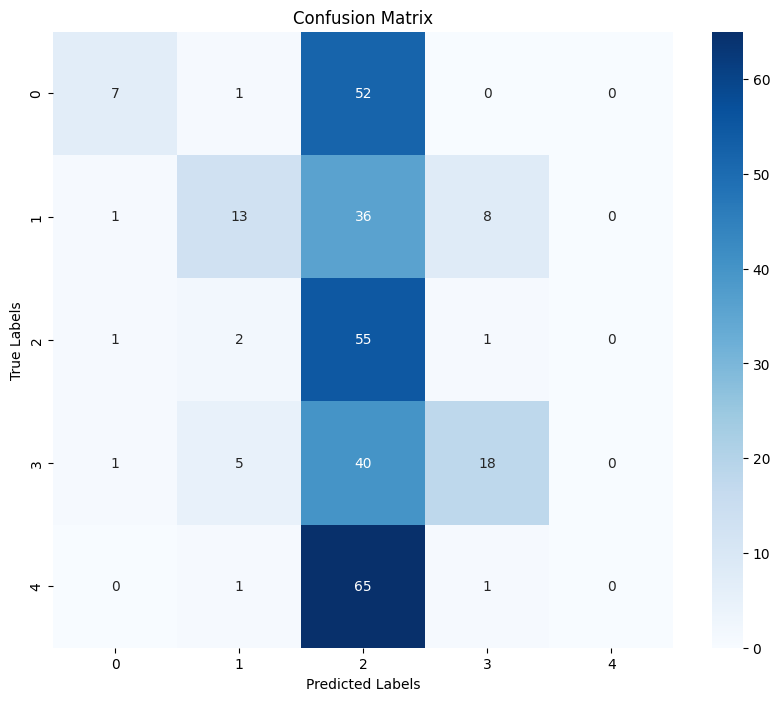

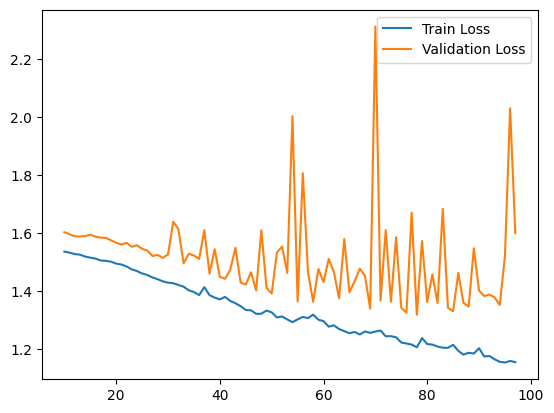

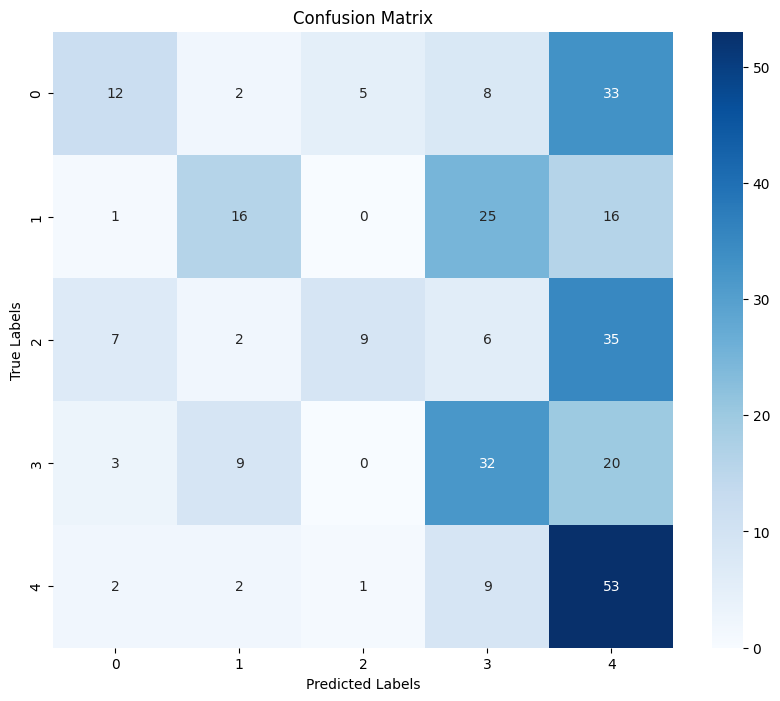

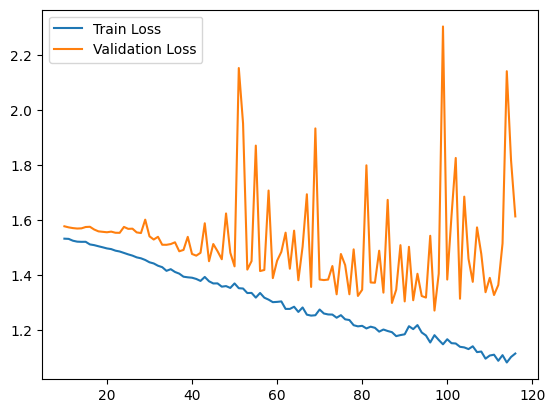

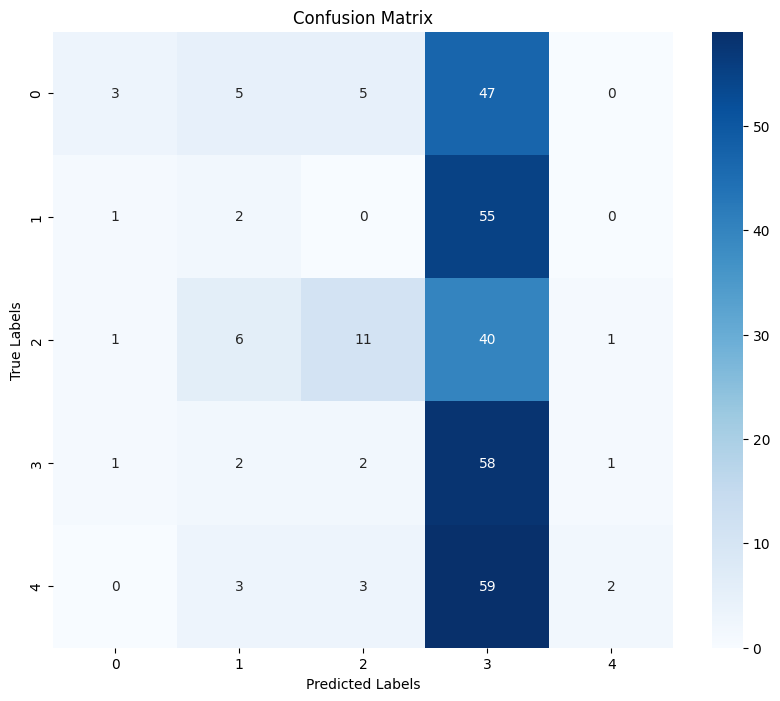

In [4]:
results = load_results('./checkpoints/cls/Haptics/FCN/data.json')

metrics = get_cls_metrics(results)
print('  Acurácia: ', np.round(metrics['mean_acc'],2), '+-', np.round(metrics['std_acc'],2))
print('  F1 Macro: ', np.round(metrics['mean_f1_macro'],2), '+-', np.round(metrics['std_f1_macro'],2))
print('  F1 Micro: ', np.round(metrics['mean_f1_micro'],2), '+-', np.round(metrics['std_f1_micro'],2))
print('Time (sec): ', np.round(metrics['mean_time'],2), '+-', np.round(metrics['std_time'],2))

for i in range(N_EXP):
    plot_loss_graph(results, i)
    plot_confusion_matrix(results, i)

## Extrinsic Regression

In [5]:
results

[{'train_losses': [1.6201419234275818,
   1.585414469242096,
   1.572493851184845,
   1.5626009106636047,
   1.5509740710258484,
   1.5459254384040833,
   1.5447384715080261,
   1.5423637628555298,
   1.5337791442871094,
   1.5347102880477905,
   1.528228521347046,
   1.52321457862854,
   1.5204426646232605,
   1.5175679326057434,
   1.5130574107170105,
   1.5117874145507812,
   1.5054759979248047,
   1.500861644744873,
   1.4936596155166626,
   1.4926717877388,
   1.4869104623794556,
   1.4837281107902527,
   1.4814846515655518,
   1.4745294451713562,
   1.4697076678276062,
   1.4640643000602722,
   1.4564939737319946,
   1.4531895518302917,
   1.4458492398262024,
   1.452191948890686,
   1.4397960901260376,
   1.435535967350006,
   1.4324527978897095,
   1.4177822470664978,
   1.417771577835083,
   1.4147774577140808,
   1.4075065851211548,
   1.4052563309669495,
   1.4041184186935425,
   1.3929831981658936,
   1.3872674703598022,
   1.3854017853736877,
   1.3748710751533508,
   1.36

       MSE:  0.01 +- 0.0
      RMSE:  0.07 +- 0.02
       MAE:  0.06 +- 0.02
y_true std:  0.04
Time (sec):  0.4 +- 0.23


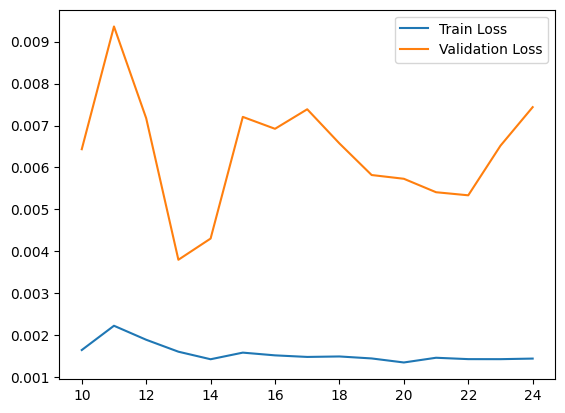

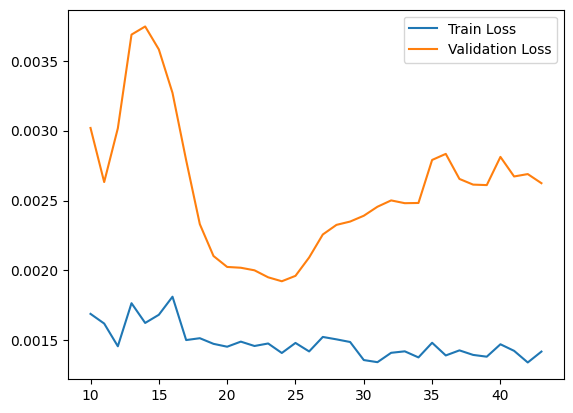

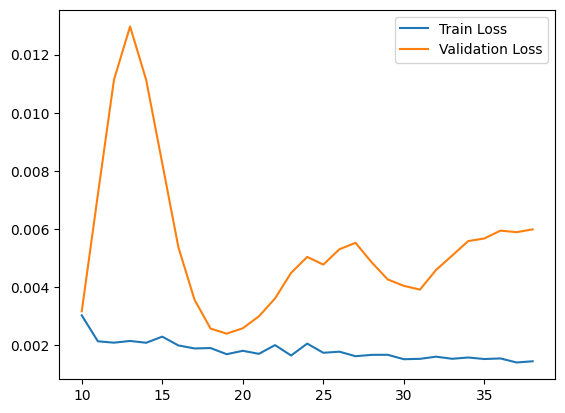

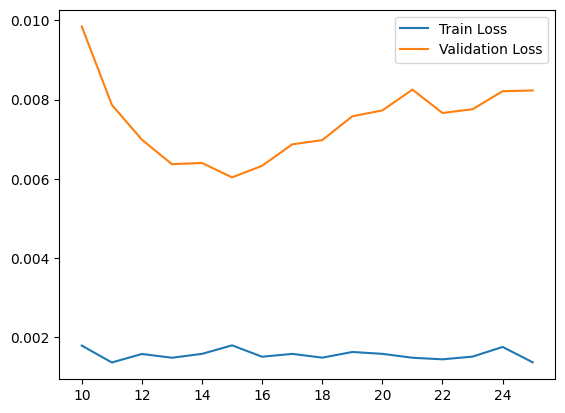

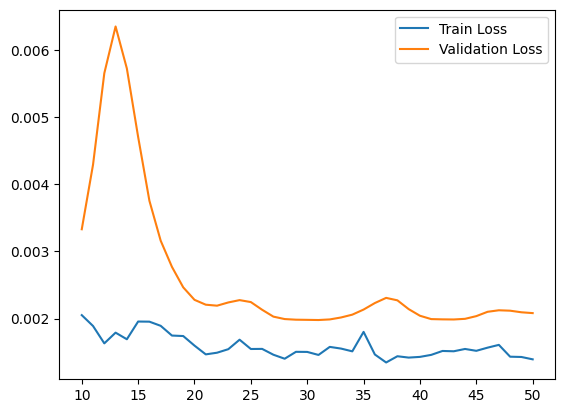

In [6]:
from aeon.datasets import load_regression
X_test, y_test = load_regression('Covid3Month', split="test")

results = load_results('./checkpoints/tser/Covid3Month/FCN/data.json')

metrics = get_tser_metrics(results)
print('       MSE: ', np.round(metrics['mean_mse'],2), '+-', np.round(metrics['std_mse'],2))
print('      RMSE: ', np.round(metrics['mean_rmse'],2), '+-', np.round(metrics['std_rmse'],2))
print('       MAE: ', np.round(metrics['mean_mae'],2), '+-', np.round(metrics['std_mae'],2))
print('y_true std: ', np.round(np.std(y_test),2))
print('Time (sec): ', np.round(metrics['mean_time'],2), '+-', np.round(metrics['std_time'],2))

for i in range(N_EXP):
    plot_loss_graph(results, i)